In [2]:
'''
In this notebook we will analyze the metric runs we've done already
'''

"\nIn this notebook we will analyze the metric runs we've done already\n"

In [51]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os

In [3]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = None
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [4]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "new_names_local_GRBafterglows_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/lustre/lrspec/us

[INFO] Loaded metric module: new_names_local_GRBafterglows_metric
[INFO] Loaded shared_utils module


In [11]:
#metric configurations
testname=None  #use this to add text if you're testing something other than the below variables
testname_metric_only=None

#population variables
rate_density = 1e-7

# apply None for non-use case 
z_min, z_max = .00226, .3
d_min, d_max = None, None #3000, 4000

#other
use_extinction = False
ignore_triples = False #turn this to true to ignore triples

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']

# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname, testname_metric_only=testname_metric_only,
                        science_case="GRBafterglows", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir = paths

to_load = df_file+"ObsRecords_"+cadences[0]+'.csv'

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [12]:
df_obs = pd.read_csv(to_load)

In [387]:
importlib.reload(metric)

<module 'new_names_local_GRBafterglows_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/GRBafterglows/new_names_local_GRBafterglows_metric.py'>

(40.0, 5.0)

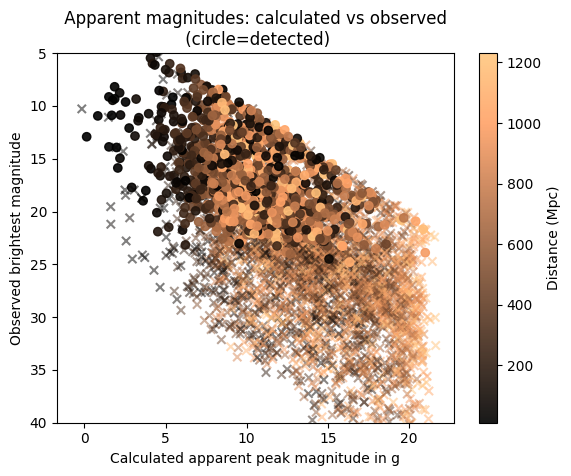

In [13]:
fig, ax = plt.subplots()
not_detected_df = df_obs[df_obs['detected']==False]
detected_df = df_obs[df_obs['detected']==True]
plt.scatter(not_detected_df['peak_apparent_mag_g_noebv'], not_detected_df['peak_mag_observed'], marker='x',c=not_detected_df['distance_Mpc'], alpha=.5, cmap='copper')
plt.scatter(detected_df['peak_apparent_mag_g_noebv'], detected_df['peak_mag_observed'], marker='o',c=detected_df['distance_Mpc'], alpha=.9, cmap='copper')
plt.title(" Apparent magnitudes: calculated vs observed \n (circle=detected)")
plt.xlabel("Calculated apparent peak magnitude in g")
plt.ylabel("Observed brightest magnitude")
ax.yaxis.set_inverted(True)
plt.colorbar(label="Distance (Mpc)")
plt.ylim(40,5)

In [8]:
def get_df(cadence_num, testname_metric_only = None, testname=None, use_extinction = False,ignore_triples = False):
    '''
    easy way to load the obs record dfs 
    use when rate_density = 1e-8
    cadence_num: 0,1,2, or 'all', depending on which cadence you want
    returns df, or if cadence_num='all', returns 3 df
    cadences go in order:['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']
    '''
    
    rate_density = 1e-8

    # apply None for non-use case 
    z_min, z_max = .00226, .3
    d_min, d_max = None, None #3000, 4000

    #other
     #turn this to true to ignore triples

    #cadence variables
    cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']

    # paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
    paths = shared_utils.build_filenames(testname=testname,testname_metric_only=testname_metric_only,
                            science_case="GRBafterglows", 
                            rate_density=rate_density, 
                            z_min=z_min, 
                            z_max=z_max,
                            d_min=d_min, 
                            d_max=d_max,
                            ignore_triples=ignore_triples,                   
                            use_extinction=use_extinction,
                            base_dir=base_dir)
    

    templates_file, pop_file, df_file, storage_dir, summary_file = paths
    
    # print(to_load)
    if cadence_num == 'all':
        to_load = df_file+"ObsRecords_"+cadences[0]+'.csv'
        to_load1 = df_file+"ObsRecords_"+cadences[1]+'.csv'
        to_load2 = df_file+"ObsRecords_"+cadences[2]+'.csv'
        return pd.read_csv(to_load), pd.read_csv(to_load1), pd.read_csv(to_load2)
    to_load = df_file+"ObsRecords_"+cadences[cadence_num]+'.csv'
    return pd.read_csv(to_load)

In [15]:
df_obs_4roll, df_obs_baseline,df_obs_noroll = get_df('all')


GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [64]:
# dfs = {'baseline_MAXGAP_100' :df_obs_baseline_MAXGAP_100,
#        '4roll_MAXGAP_100': df_obs_4roll_MAXGAP_100,
#        'baseline_MAXGAP_1' :df_obs_baseline,
#        '4roll_MAXGAP_1' :df_obs_4roll,
#        'baseline_MAXGAP_0.5' :df_obs_baseline_MAXGAP_p5,
#        '4roll_MAXGAP_0.5' :df_obs_4roll_MAXGAP_p5}


Text(0.5, 0, 'Number of observations of a single light curve')

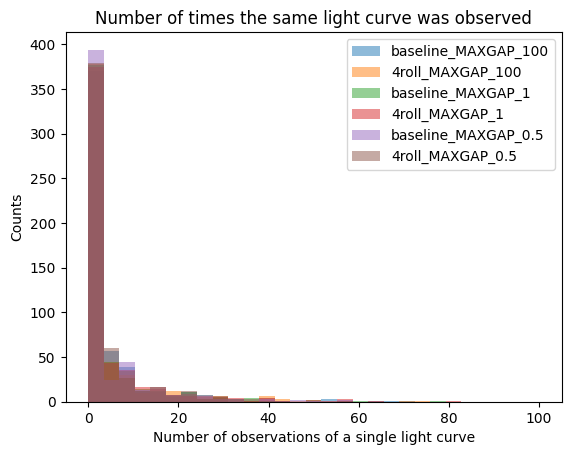

In [90]:
for key, value in dfs.items():
    plt.hist(value['n_observations_detected'],bins=np.linspace(0,100,30),label=key,alpha=.5)
# plt.ylim(0,100)
plt.legend()
plt.title("Number of times the same light curve was observed")
plt.ylabel("Counts")
plt.xlabel("Number of observations of a single light curve")

Text(0.5, 0, 'Number of detections in a single light curve')

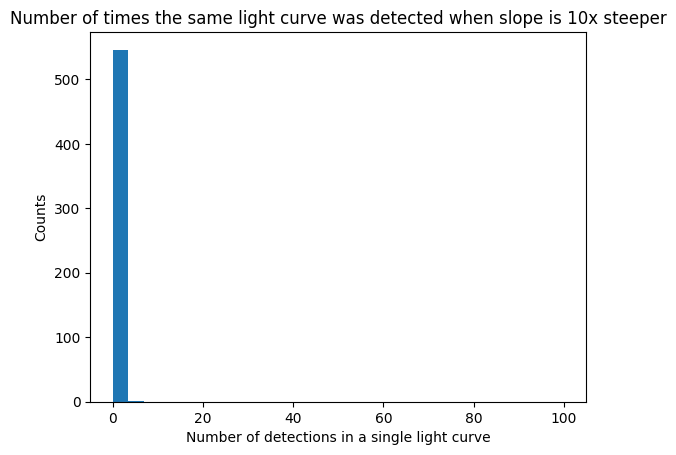

In [88]:
plt.hist(df_obs_baseline_MAXGAP_100_alpha10x['n_observations_detected'],bins=np.linspace(0,100,30))
plt.title("Number of times the same light curve was detected when slope is 10x steeper")
plt.ylabel("Counts")
plt.xlabel("Number of detections in a single light curve")

In [7]:
def get_df_big(cadence_num, testname_metric_only = None, testname=None,use_extinction = False,ignore_triples = False):
    '''
    easy way to load the obs record dfs 
    use when rate_density = 1e-7
    cadence_num: 0,1,2, or 'all', depending on which cadence you want
    returns df, or if cadence_num='all', returns 3 df
    cadences go in order:['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']
    '''
    rate_density = 1e-7

    # apply None for non-use case 
    z_min, z_max = .00226, .3
    d_min, d_max = None, None #3000, 4000

    #other
    
     #turn this to true to ignore triples

    #cadence variables
    cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']

    # paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
    paths = shared_utils.build_filenames(testname=testname,testname_metric_only=testname_metric_only,
                            science_case="GRBafterglows", 
                            rate_density=rate_density, 
                            z_min=z_min, 
                            z_max=z_max,
                            d_min=d_min, 
                            d_max=d_max,
                            ignore_triples=ignore_triples,                   
                            use_extinction=use_extinction,
                            base_dir=base_dir)
    

    templates_file, pop_file, df_file, storage_dir, summary_file = paths

    
    # print(to_load)
    if cadence_num == 'all':
        to_load = df_file+"ObsRecords_"+cadences[0]+'.csv'
        to_load1 = df_file+"ObsRecords_"+cadences[1]+'.csv'
        to_load2 = df_file+"ObsRecords_"+cadences[2]+'.csv'
        return pd.read_csv(to_load), pd.read_csv(to_load1), pd.read_csv(to_load2)
    to_load = df_file+"ObsRecords_"+cadences[cadence_num]+'.csv'
    return pd.read_csv(to_load)

In [127]:
importlib.reload(metric)

<module 'new_names_local_GRBafterglows_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/GRBafterglows/new_names_local_GRBafterglows_metric.py'>

In [231]:
def make_table(testname_metric_only, title=None):
    big_df_obs_4roll, big_df_obs_baseline, big_df_obs_noroll = get_df_big('all', testname_metric_only)
    if testname_metric_only=="None" or testname_metric_only==None:
        big_df_obs_4roll_MAXGAP_100, big_df_obs_baseline_MAXGAP_100, big_df_obs_noroll_MAXGAP_100 = get_df_big('all', 'MAXGAP_100')
        big_df_obs_4roll_MAXGAP_p5, big_df_obs_baseline_MAXGAP_p5, big_df_obs_noroll_MAXGAP_p5 = get_df_big('all', 'MAXGAP_p5')
    else:
        big_df_obs_4roll_MAXGAP_100, big_df_obs_baseline_MAXGAP_100, big_df_obs_noroll_MAXGAP_100 = get_df_big('all', testname_metric_only+'_MAXGAP_100')
        big_df_obs_4roll_MAXGAP_p5, big_df_obs_baseline_MAXGAP_p5, big_df_obs_noroll_MAXGAP_p5 = get_df_big('all', testname_metric_only+'_MAXGAP_p5')
    if title ==None:
        print(f"\nRequiring {testname_metric_only} \n")
    if title != None:
        print(f"\nRequiring {title} \n")
    print('               no roll, baseline, 4 roll')
    print('no maxgap      ',np.sum(big_df_obs_noroll_MAXGAP_100['detected']==True),np.sum(big_df_obs_baseline_MAXGAP_100['detected']==True),np.sum(big_df_obs_4roll_MAXGAP_100['detected']==True))
    print('maxgap 1 day   ',np.sum(big_df_obs_noroll['detected']==True),np.sum(big_df_obs_baseline['detected']==True),np.sum(big_df_obs_4roll['detected']==True))
    print('maxgap 0.5 day ',np.sum(big_df_obs_noroll_MAXGAP_p5['detected']==True),np.sum(big_df_obs_baseline_MAXGAP_p5['detected']==True),np.sum(big_df_obs_4roll_MAXGAP_p5['detected']==True))
   
    
    

In [259]:
make_table(None, title="two observations above snr 5 in any filter")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring two observations above snr 5 in any filter 

               no roll, baseline, 4 roll
no maxgap       1400 1415 1350
maxgap 1 day    1048 1070 1058
maxgap 0.5 day  971 1004 984


In [240]:
make_table_1detect('1detect_1filt_r', title="one observation above snr 5 in r")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring one observation above snr 5 in r 

no roll, baseline, 4 roll
1639 1627 1612


In [241]:
make_table_1detect('1detect_1filt_g', title="one observation above snr 5 in g")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring one observation above snr 5 in g 

no roll, baseline, 4 roll
1216 1212 1190


In [237]:
make_table('2detect_1filt_r', title="two observations above snr 5 in r")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring two observations above snr 5 in r 

               no roll, baseline, 4 roll
no maxgap       1034 1032 965
maxgap 1 day    565 569 579
maxgap 0.5 day  482 507 501


In [232]:
make_table('2detect_1filt_g', title="two observations above snr 5 in g")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring two observations above snr 5 in g 

               no roll, baseline, 4 roll
no maxgap       546 591 596
maxgap 1 day    238 288 275
maxgap 0.5 day  209 261 242


In [242]:
make_table_1detect('1detect', title="one observation above snr 5 in any filter")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring one observation above snr 5 in any filter 

no roll, baseline, 4 roll
2112 2101 2106


In [239]:
def make_table_1detect(testname_metric_only, title=None):
    big_df_obs_4roll, big_df_obs_baseline, big_df_obs_noroll = get_df_big('all', testname_metric_only)
    if title ==None:
        print(f"\nRequiring {testname_metric_only} \n")
    if title != None:
        print(f"\nRequiring {title} \n")
    print('no roll, baseline, 4 roll')
    # print(np.sum(big_df_obs_noroll['n_observations_detected']>=1),np.sum(big_df_obs_baseline['n_observations_detected']>=1),np.sum(big_df_obs_4roll['n_observations_detected']>=1))
    print(np.sum(big_df_obs_noroll['detected']==True),np.sum(big_df_obs_baseline['detected']==True),np.sum(big_df_obs_4roll['detected']==True))


In [283]:
canon_4roll_no_ebv, canon_baseline_no_ebv, canon_noroll_no_ebv, = get_df('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [286]:
canon_4roll_w_ebv, canon_baseline_w_ebv, canon_noroll_w_ebv, = get_df('all', testname_metric_only = None, testname=None, use_extinction=True)

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [293]:
big_4roll_no_ebv, big_baseline_no_ebv, big_noroll_no_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [294]:
big_4roll_w_ebv, big_baseline_w_ebv, big_noroll_w_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=True)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [297]:
len(big_4roll_w_ebv[big_4roll_w_ebv['detected']==True])

969

In [360]:
len(big_4roll_no_ebv[big_4roll_no_ebv['detected']==True])

1058

In [301]:
detected = big_4roll_no_ebv[big_4roll_no_ebv['detected']==True]

(array([220., 161., 165., 184., 134., 100.,  49.,  30.,  12.,   3.]),
 array([2.26901026e-02, 9.61904444e+00, 1.92153988e+01, 2.88117531e+01,
        3.84081074e+01, 4.80044618e+01, 5.76008161e+01, 6.71971705e+01,
        7.67935248e+01, 8.63898791e+01, 9.59862335e+01]),
 <BarContainer object of 10 artists>)

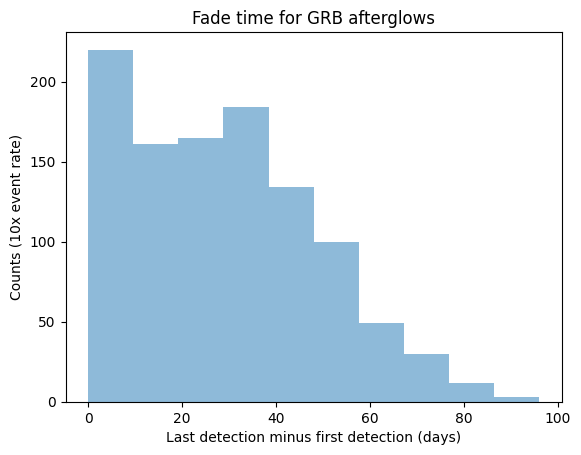

In [308]:
plt.title("Fade time for GRB afterglows")
plt.xlabel("Last detection minus first detection (days)")
plt.ylabel("Counts (10x event rate)")
plt.hist(detected['last_det_mjd']-detected['first_det_mjd'],alpha=.5)

In [313]:
import ast


In [330]:
#what i want is time until it's below 21st mag
#to do that i need to get into the stupid list
detected.iloc[0]['mag_obs']
mags = np.array(ast.literal_eval(detected.iloc[0]['mag_obs']))
mjd = np.array(ast.literal_eval(detected.iloc[0]['mjd_obs']))
snrs = np.array(ast.literal_eval(detected.iloc[0]['snr_obs']))

In [338]:
days_above_21 = []
for i,row in detected.iterrows():
    mags = np.array(ast.literal_eval(row['mag_obs']))
    mjd = np.array(ast.literal_eval(row['mjd_obs']))
    if np.sum(mags<21)>0:
        mjd_above_21 = mjd[mags<21]
        days_above_21.append(np.max(mjd_above_21)-np.min(mjd_above_21))
    else:
        days_above_21.append(0)
    

(array([143.,  77.,  74.,  87.,  71.,  94., 100.,  84.,  75.,  59.,  51.,
         49.,  29.,  20.,  18.,  12.,   4.,   8.,   1.,   2.]),
 array([2.26901026e-02, 4.82086727e+00, 9.61904444e+00, 1.44172216e+01,
        1.92153988e+01, 2.40135759e+01, 2.88117531e+01, 3.36099303e+01,
        3.84081074e+01, 4.32062846e+01, 4.80044618e+01, 5.28026389e+01,
        5.76008161e+01, 6.23989933e+01, 6.71971705e+01, 7.19953476e+01,
        7.67935248e+01, 8.15917020e+01, 8.63898791e+01, 9.11880563e+01,
        9.59862335e+01]),
 <BarContainer object of 20 artists>)

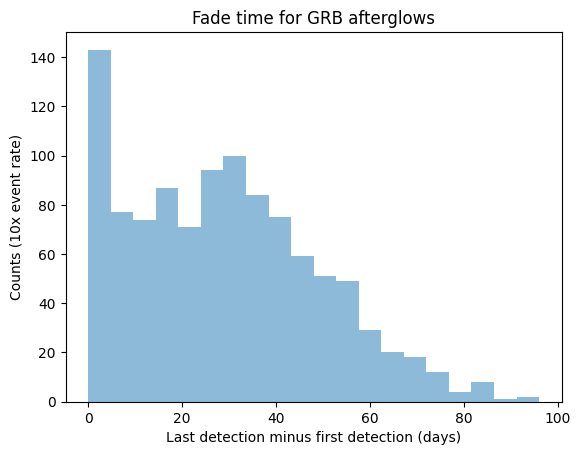

In [343]:
plt.title("Fade time for GRB afterglows")
plt.xlabel("Last detection minus first detection (days)")
plt.ylabel("Counts (10x event rate)")
plt.hist(detected['last_det_mjd']-detected['first_det_mjd'],alpha=.5, bins=20)

(array([429.,  77.,  80.,  89.,  70.,  57.,  63.,  46.,  38.,  27.,  23.,
         22.,  14.,   9.,   6.,   1.,   2.,   1.,   0.,   4.]),
 array([ 0.        ,  4.29089221,  8.58178441, 12.87267662, 17.16356882,
        21.45446103, 25.74535324, 30.03624544, 34.32713765, 38.61802985,
        42.90892206, 47.19981427, 51.49070647, 55.78159868, 60.07249088,
        64.36338309, 68.6542753 , 72.9451675 , 77.23605971, 81.52695191,
        85.81784412]),
 <BarContainer object of 20 artists>)

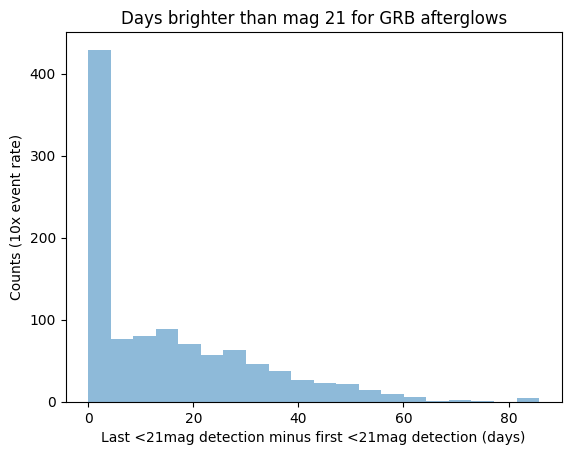

In [344]:

plt.title("Days brighter than mag 21 for GRB afterglows")
plt.xlabel("Last <21mag detection minus first <21mag detection (days)")
plt.ylabel("Counts (10x event rate)")
plt.hist(days_above_21,alpha=.5,bins=20)

In [373]:
def plot_observed_light_curve(row, log=True, ylim=True):
    '''
    takes a row from an obs dataframe, for instance: detected_df.iloc[4]
    returns nothing
    plots the observed light curve with each filter
    as a random color
    and events with snr>5 are bigger (open circles)
    nondetections are small dots
    '''
    unique_filters = np.unique(ast.literal_eval(row['filter']))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_filters)))
    filter_to_color = dict(zip(unique_filters, colors))
    color_array = np.array([filter_to_color[f] for f in ast.literal_eval(row['filter'])])

    mjds = np.array(ast.literal_eval(row['mjd_obs']))
    snrs = np.array(ast.literal_eval(row['snr_obs']))
    mags = np.array(ast.literal_eval(row['mag_obs']))

    snr_mask = snrs > 5  
    snr_to_marker = {False: '.', True: 'o'}

    # plt.figure(figsize=(10, 6))

    # Loop over each filter and SNR condition
    for snr_cond in [True, False]:
            if np.any(snr_mask):  # Only plot if there are matching points
                if log:
                    plt.scatter(
                        np.log10(np.array(mjds)[snr_mask]),
                        np.array(mags)[snr_mask],
                        c=color_array[snr_mask],
                        marker=snr_to_marker[snr_cond]
                    )
                else:
                    plt.scatter(
                        np.array(mjds)[snr_mask],
                        np.array(mags)[snr_mask],
                        c=color_array[snr_mask],
                        marker=snr_to_marker[snr_cond]
                    )

    if log:
        plt.xlim(np.log10(np.array(row['peak_mjd_observed']) - 10), np.log10(np.array(row['peak_mjd_observed']) + 100))
    else:
        plt.xlim(np.array(row['peak_mjd_observed']) - 10, np.array(row['peak_mjd_observed']) + 100)
    plt.gca().invert_yaxis()
    if log:
        plt.xlabel("log MJD")
    else:
        plt.xlabel("MJD")
    plt.ylabel("Apparent mag")
    plt.title("Light Curve as Observed")
    plt.legend(["Large means detected",
                "Each color is a filter"])
    plt.tight_layout()
    if ylim==True:
        plt.ylim(40,16)
    # plt.xscale("log")
    plt.show()

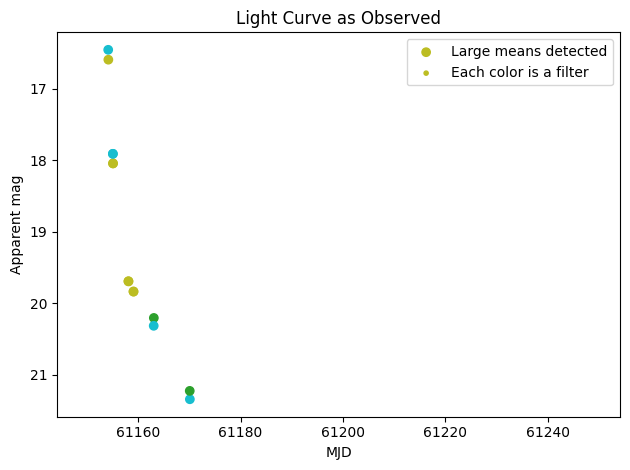

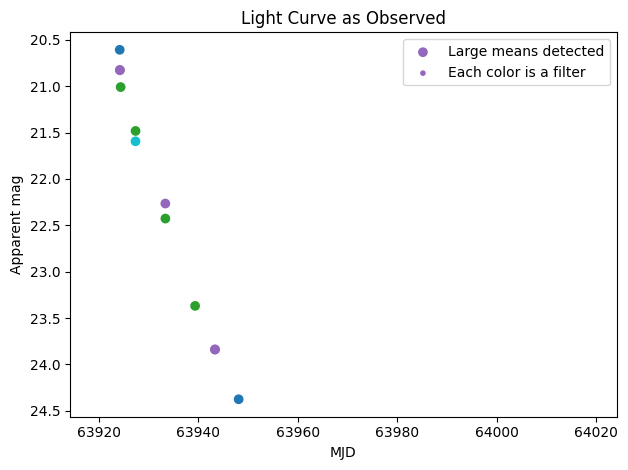

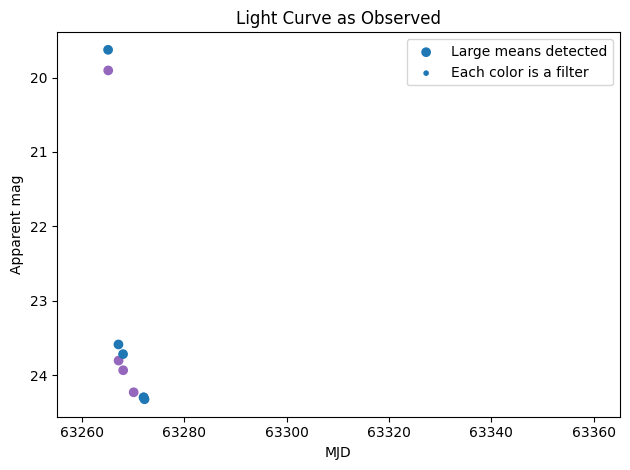

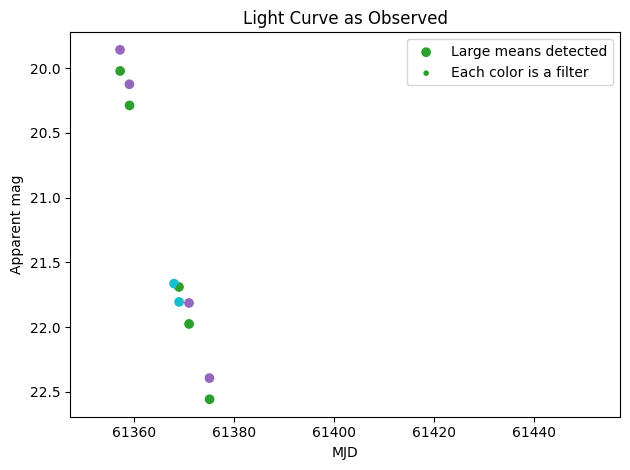

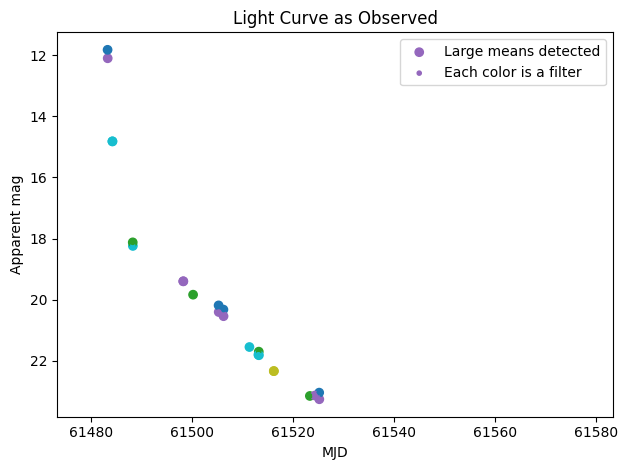

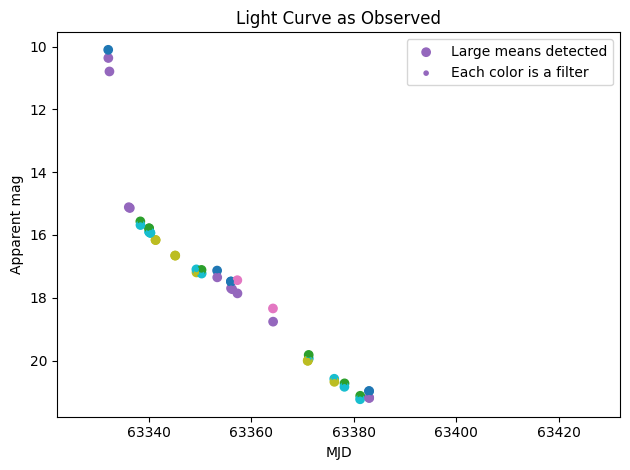

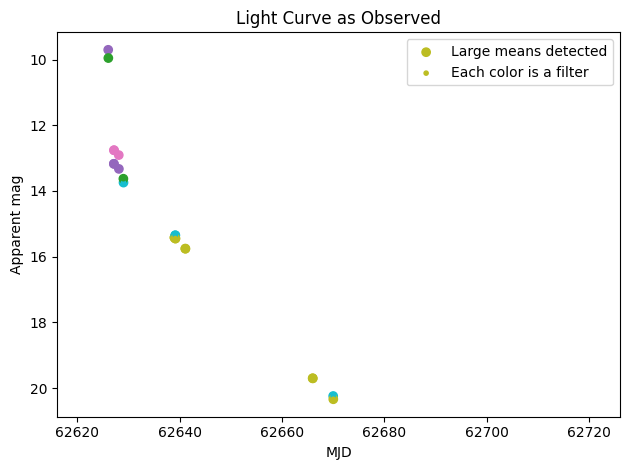

In [374]:
num_plotted=0
for i, row in detected.iterrows():
    plot_observed_light_curve(row,log=False,ylim=False)
    if num_plotted>5:
        break
    num_plotted+=1

In [9]:
big_4roll_w_ebv, big_baseline_w_ebv, big_noroll_w_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=True)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [12]:
big_4roll_no_ebv, big_baseline_no_ebv, big_noroll_no_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [11]:
np.sum(big_4roll_w_ebv['detected']==True),np.sum(big_baseline_w_ebv['detected']==True)

(np.int64(969), np.int64(979))

In [46]:
(979-969)/979

0.010214504596527068

In [13]:
np.sum(big_4roll_no_ebv['detected']==True),np.sum(big_baseline_no_ebv['detected']==True)

(np.int64(1058), np.int64(1070))

In [17]:
np.average(big_4roll_w_ebv['n_observations_detected']),np.average(big_baseline_w_ebv['n_observations_detected'])

(np.float64(3.921253965292032), np.float64(3.943583037549038))

In [18]:
np.average(big_4roll_w_ebv['n_filters_detected']),np.average(big_baseline_w_ebv['n_filters_detected'])

(np.float64(1.2300802388505319), np.float64(1.2570521203063703))

In [48]:
#number of observations in detected obsercations
detected_big_4roll_w_ebv = big_4roll_w_ebv[big_4roll_w_ebv['detected']==True]
detected_big_baseline_w_ebv = big_baseline_w_ebv[big_baseline_w_ebv['detected']==True]


In [49]:
np.average(detected_big_4roll_w_ebv['n_observations_detected']),np.average(detected_big_baseline_w_ebv['n_observations_detected'])

(np.float64(18.13003095975232), np.float64(17.84065372829418))

In [50]:
big_4roll_w_ebv

,sid,mjd_obs,mag_obs,snr_obs,filter,first_det_mjd,last_det_mjd,fade_time_days,sid_duplicate,file_indx,...,detected,theta_obs,distance_modulus,year,n_observations_detected,n_filters_detected,peak_abs_mag_g,alpha_fade_g,t_jetbreak_g,peak_apparent_mag_g_noebv
0,1,"[64347.14632091699, 64347.12356130418, 64291.2...","[27.797270769387573, 27.793542906539518, 137.2...","[0.02148259165175206, 0.02169029660605208, 6.3...","['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...",64327.124736,64327.128764,8.291737,1,738,...,False,0.689389,38.260862,10,2,1,-19.752437,-15.471453,0.669341,18.508425
1,2,"[61728.131224077966, 62454.3016272885, 62454.2...","[138.60813876895963, 138.4997750855547, 138.49...","[1.6550352795007434e-45, 2.1509022233746693e-4...","['g', 'y', 'y', 'z', 'r', 'z', 'y', 'y', 'r', ...",NaN,NaN,NaN,2,252,...,False,1.348682,39.439547,8,0,0,-27.520433,-18.996740,-2.366441,11.919115
2,3,"[63420.19647675333, 61884.385486063686, 61884....","[139.80788955141355, 139.9577098577801, 140.17...","[9.367313512020692e-47, 2.6106390063376487e-46...","['i', 'r', 'g', 'r', 'i', 'r', 'g', 'r', 'z', ...",63046.195834,63047.216099,1.078620,3,653,...,True,1.095423,40.332861,6,4,2,-23.803428,-15.381668,-0.983948,16.529433
3,4,"[61461.32059103347, 61479.347512385575, 63769....","[138.61004030180231, 138.6529251197292, 138.61...","[4.860642818767038e-47, 1.081470886717104e-45,...","['y', 'r', 'z', 'i', 'r', 'y', 'i', 'u', 'z', ...",NaN,NaN,NaN,4,526,...,False,0.147933,39.569801,5,0,0,-18.800951,-8.201270,4.391512,20.768849
4,5,"[61490.332320421156, 61490.30894890274, 63301....","[139.4968355187295, 139.4968355187295, 139.648...","[4.313854345470791e-47, 6.387236533543844e-47,...","['y', 'y', 'r', 'i', 'g', 'z', 'r', 'i', 'r', ...",NaN,NaN,NaN,5,366,...,False,1.532504,40.354635,10,0,0,-20.563710,-15.863329,1.104865,19.790925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5354,7892,"[63264.187567218476, 63650.1241760822, 62094.3...","[139.31438224135468, 139.31438224135468, 139.3...","[1.6741750678294908e-46, 2.256110645692153e-46...","['r', 'r', 'r', 'r', 'i', 'i', 'i', 'g', 'r', ...",NaN,NaN,NaN,7892,554,...,False,0.162010,40.199940,5,0,0,-21.583447,-14.944249,-2.436546,18.616493
5355,7894,"[64019.16500403325, 64363.243184675666, 64019....","[135.9591815264451, 136.05130557243615, 135.95...","[3.6996476466134436e-45, 4.3092375749807666e-4...","['z', 'u', 'y', 'r', 'z', 'r', 'y', 'i', 'y', ...",NaN,NaN,NaN,7894,132,...,False,0.602321,36.912929,6,0,0,-21.025497,-14.305094,-0.098620,15.887432
5356,7896,"[61080.200939067356, 61055.1175234967, 62194.1...","[139.3379285020505, 139.54506172149252, 138.89...","[5.0396490401165304e-46, 1.8752470185286344e-4...","['g', 'u', 'y', 'y', 'y', 'y', 'r', 'r', 'u', ...",NaN,NaN,NaN,7896,512,...,False,0.917470,39.646528,8,0,0,-21.592560,-11.765264,1.067851,18.053968
5357,7897,"[63315.0802777019, 63315.05707183516, 61781.23...","[133.1374865878937, 133.1374865878937, 133.177...","[1.288053706644146e-44, 1.5697710521791085e-44...","['y', 'y', 'i', 'z', 'r', 'y', 'u', 'z', 'z', ...",63156.343816,63197.168967,99.936693,7897,686,...,True,0.116306,34.066556,6,17,4,-30.143996,-25.434491,-13.011807,3.922560


In [23]:
import healpy as hp

In [30]:
fourroll_no_ebv, baseline_no_ebv, noroll_no_ebv, = get_df('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


Text(0, 0.5, 'counts')

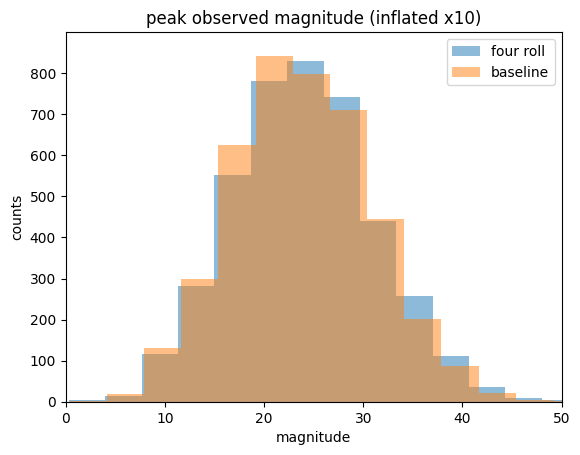

In [47]:
plt.hist(big_4roll_w_ebv['peak_mag_observed'], alpha=.5,label='four roll',bins=40)
plt.hist(big_baseline_w_ebv['peak_mag_observed'], alpha=.5,label='baseline',bins=40)
plt.xlim(0,50)
plt.legend()
plt.title("peak observed magnitude (inflated x10)")
plt.xlabel("magnitude")
plt.ylabel("counts")

In [53]:
def plot_map(df, title=None):
        '''
        takes obs_record dataframe, plots map of detection efficiency
        
        '''
        nside = 64
        npix = hp.nside2npix(nside)
        injected_map = np.zeros(npix)
        detected_map = np.zeros(npix)

        ra_rad = df['ra']
        dec_rad = df['dec']
        theta = 0.5 * np.pi - dec_rad
        phi = ra_rad
        pix_inds = hp.ang2pix(nside, theta, phi)

        for i, pix in enumerate(pix_inds):
            injected_map[pix] += 1
            #if detected_flags[i] :
            if df.iloc[i]['detected'] == 1:
                if np.random.rand() < 0.001:
                    print(f"[DEBUG] Detected RA, Dec: {np.degrees(ra_rad[i]):.2f}, {np.degrees(dec_rad[i]):.2f}")
                detected_map[pix] += 1

        eff_map = np.zeros(npix)
        mask = injected_map > 0
        eff_map[mask] = detected_map[mask] / injected_map[mask]
        eff_map[~mask] = hp.UNSEEN

        hp.mollview(eff_map, title=f"{title} Efficiency", unit='Efficiency', cmap='viridis')
        hp.graticule()
        plt.show

In [52]:
plot_map(fourroll_w_ebv, title='four roll w ebv')

NameError: name 'fourroll_w_ebv' is not defined

[DEBUG] Detected RA, Dec: 209.53, -34.95
[DEBUG] Detected RA, Dec: 225.00, -45.78


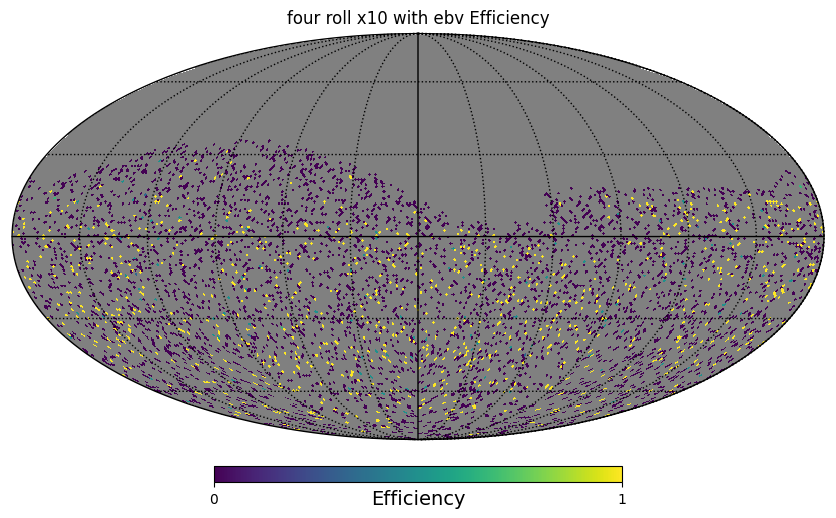

In [27]:
plot_map(big_4roll_w_ebv, title='four roll x10 with ebv')

[DEBUG] Detected RA, Dec: 134.30, -13.25


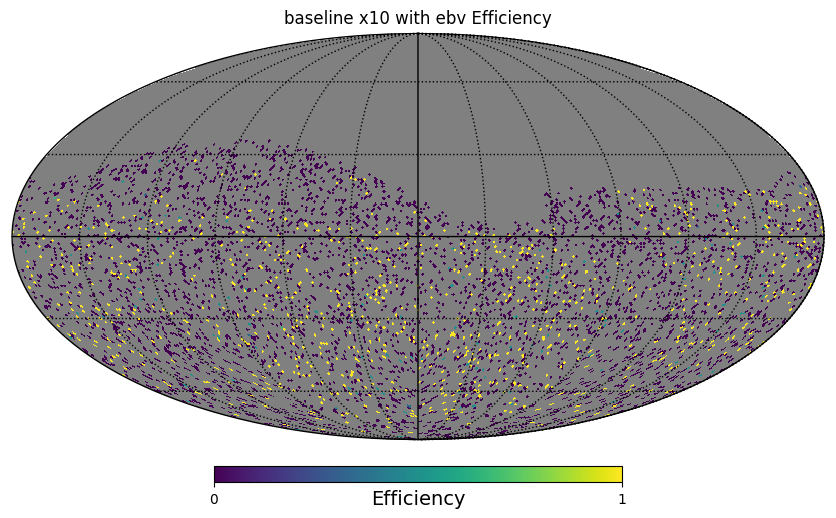

In [28]:
plot_map(big_baseline_w_ebv, title='baseline x10 with ebv')

In [56]:
big_4roll_w_ebv.iloc[0]

sid                                                                          1
mjd_obs                      [64347.14632091699, 64347.12356130418, 64291.2...
mag_obs                      [27.797270769387573, 27.793542906539518, 137.2...
snr_obs                      [0.02148259165175206, 0.02169029660605208, 6.3...
filter                       ['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...
first_det_mjd                                                     64327.124736
last_det_mjd                                                      64327.128764
fade_time_days                                                        8.291737
sid_duplicate                                                                1
file_indx                                                                  738
ra                                                                    0.613592
dec                                                                  -0.584861
distance_Mpc                                        